In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')

In [2]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv(r'D:\Machine_learning\Data_sets\creditcard.csv')
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


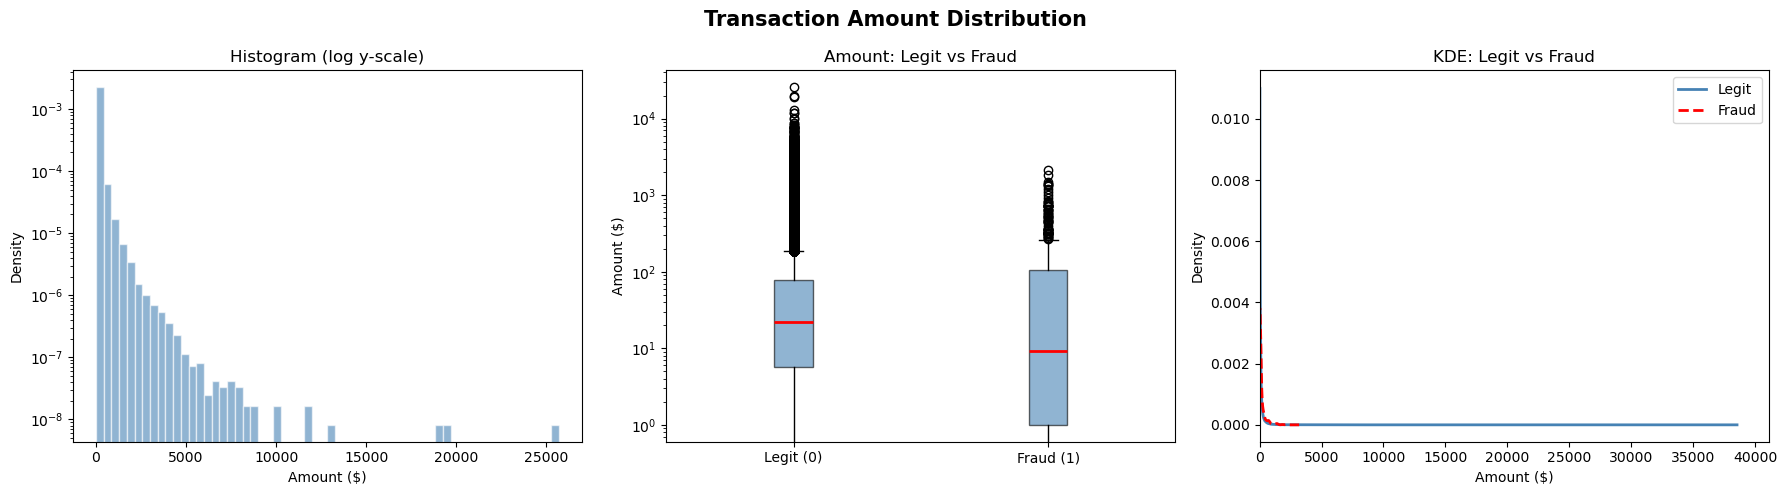

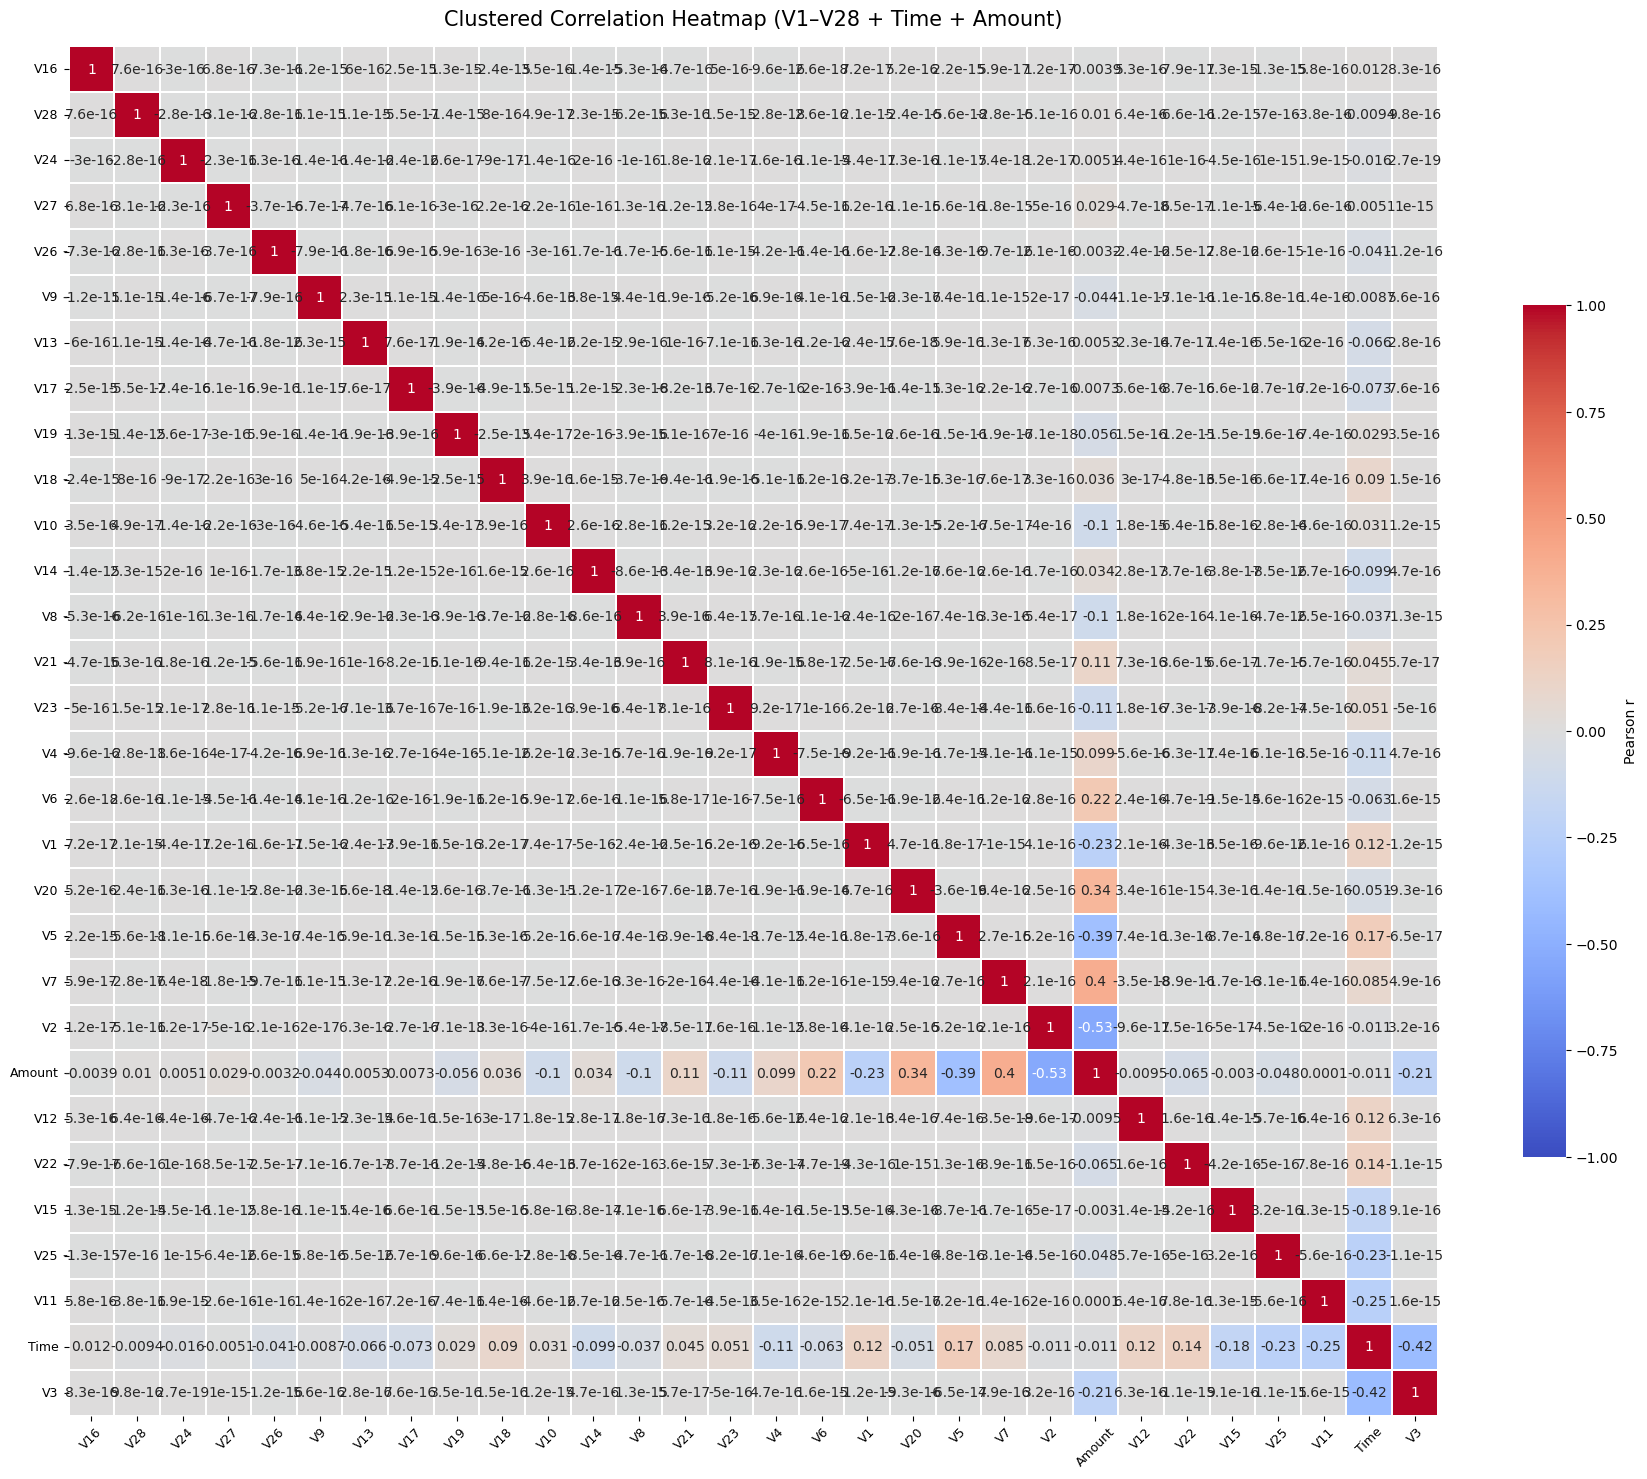

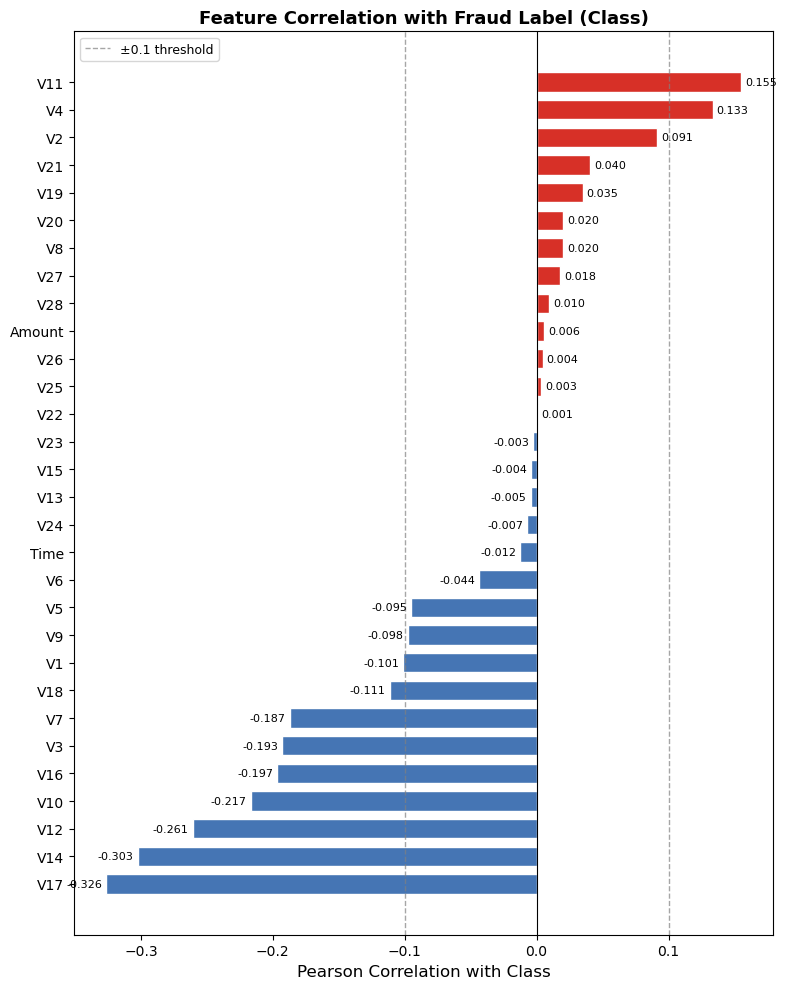


🔴 Top features POSITIVELY correlated with fraud:
V11    0.154876
V4     0.133447

🔵 Top features NEGATIVELY correlated with fraud:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V18   -0.111485
V1    -0.101347


In [8]:

# Columns: Time, V1–V28, Amount, Class
V_cols = [f"V{i}" for i in range(1, 29)]
num_cols = ["Time"] + V_cols + ["Amount"]   # exclude Class from corr matrix

corr = df[num_cols].corr()

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 1 — Transaction Amount Distribution
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Transaction Amount Distribution", fontsize=15, fontweight="bold")

# Histogram + KDE (log scale — Amount is heavily skewed)
axes[0].hist(df["Amount"], bins=60, color="steelblue", alpha=0.6,
             edgecolor="white", density=True, log=True)
axes[0].set_title("Histogram (log y-scale)")
axes[0].set_xlabel("Amount ($)")
axes[0].set_ylabel("Density")

# Box Plot: Legit vs Fraud
fraud_amounts   = df[df["Class"] == 1]["Amount"]
legit_amounts   = df[df["Class"] == 0]["Amount"]
axes[1].boxplot([legit_amounts, fraud_amounts],
                labels=["Legit (0)", "Fraud (1)"],
                patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.6),
                medianprops=dict(color="red", linewidth=2))
axes[1].set_title("Amount: Legit vs Fraud")
axes[1].set_ylabel("Amount ($)")
axes[1].set_yscale("log")

# KDE: Legit vs Fraud overlaid
legit_amounts.plot.kde(ax=axes[2], label="Legit",  color="steelblue", linewidth=2)
fraud_amounts.plot.kde(ax=axes[2], label="Fraud",  color="red",       linewidth=2, linestyle="--")
axes[2].set_title("KDE: Legit vs Fraud")
axes[2].set_xlabel("Amount ($)")
axes[2].set_xlim(left=0)
axes[2].legend()

plt.tight_layout()
plt.savefig("amount_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 2 — Clustered Correlation Heatmap (V1–V28 + Time + Amount)
# ══════════════════════════════════════════════════════════════════════════════
dist     = squareform(1 - corr.abs())
linkage  = hierarchy.linkage(dist, method="average")
order    = hierarchy.leaves_list(linkage)
corr_cl  = corr.iloc[order, order]

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(
    corr_cl,
    ax=ax,
    annot=True,
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    linewidths=0.3, linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.6, "label": "Pearson r"}
)
ax.set_title("Clustered Correlation Heatmap (V1–V28 + Time + Amount)",
             fontsize=15, pad=15)
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=9)
plt.tight_layout()
plt.savefig("heatmap_clustered.png", dpi=150, bbox_inches="tight")
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 3 — Correlation of V1–V28 + Amount + Time  WITH  Class (fraud label)
# ══════════════════════════════════════════════════════════════════════════════
class_corr = df[num_cols + ["Class"]].corr()["Class"].drop("Class").sort_values()

fig, ax = plt.subplots(figsize=(8, 10))
colors = ["#d73027" if c > 0 else "#4575b4" for c in class_corr]
ax.barh(class_corr.index, class_corr.values, color=colors, edgecolor="white", height=0.7)
ax.axvline(0,    color="black", linewidth=0.8)
ax.axvline( 0.1, color="gray",  linestyle="--", linewidth=1, alpha=0.7, label="±0.1 threshold")
ax.axvline(-0.1, color="gray",  linestyle="--", linewidth=1, alpha=0.7)
for i, val in enumerate(class_corr):
    ax.text(val + (0.003 if val >= 0 else -0.003), i,
            f"{val:.3f}", va="center",
            ha="left" if val >= 0 else "right", fontsize=8)
ax.set_xlabel("Pearson Correlation with Class", fontsize=12)
ax.set_title("Feature Correlation with Fraud Label (Class)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("class_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# PRINT — Top fraud indicators
# ══════════════════════════════════════════════════════════════════════════════
print("\n🔴 Top features POSITIVELY correlated with fraud:")
print(class_corr[class_corr > 0.1].sort_values(ascending=False).to_string())
print("\n🔵 Top features NEGATIVELY correlated with fraud:")
print(class_corr[class_corr < -0.1].sort_values().to_string())

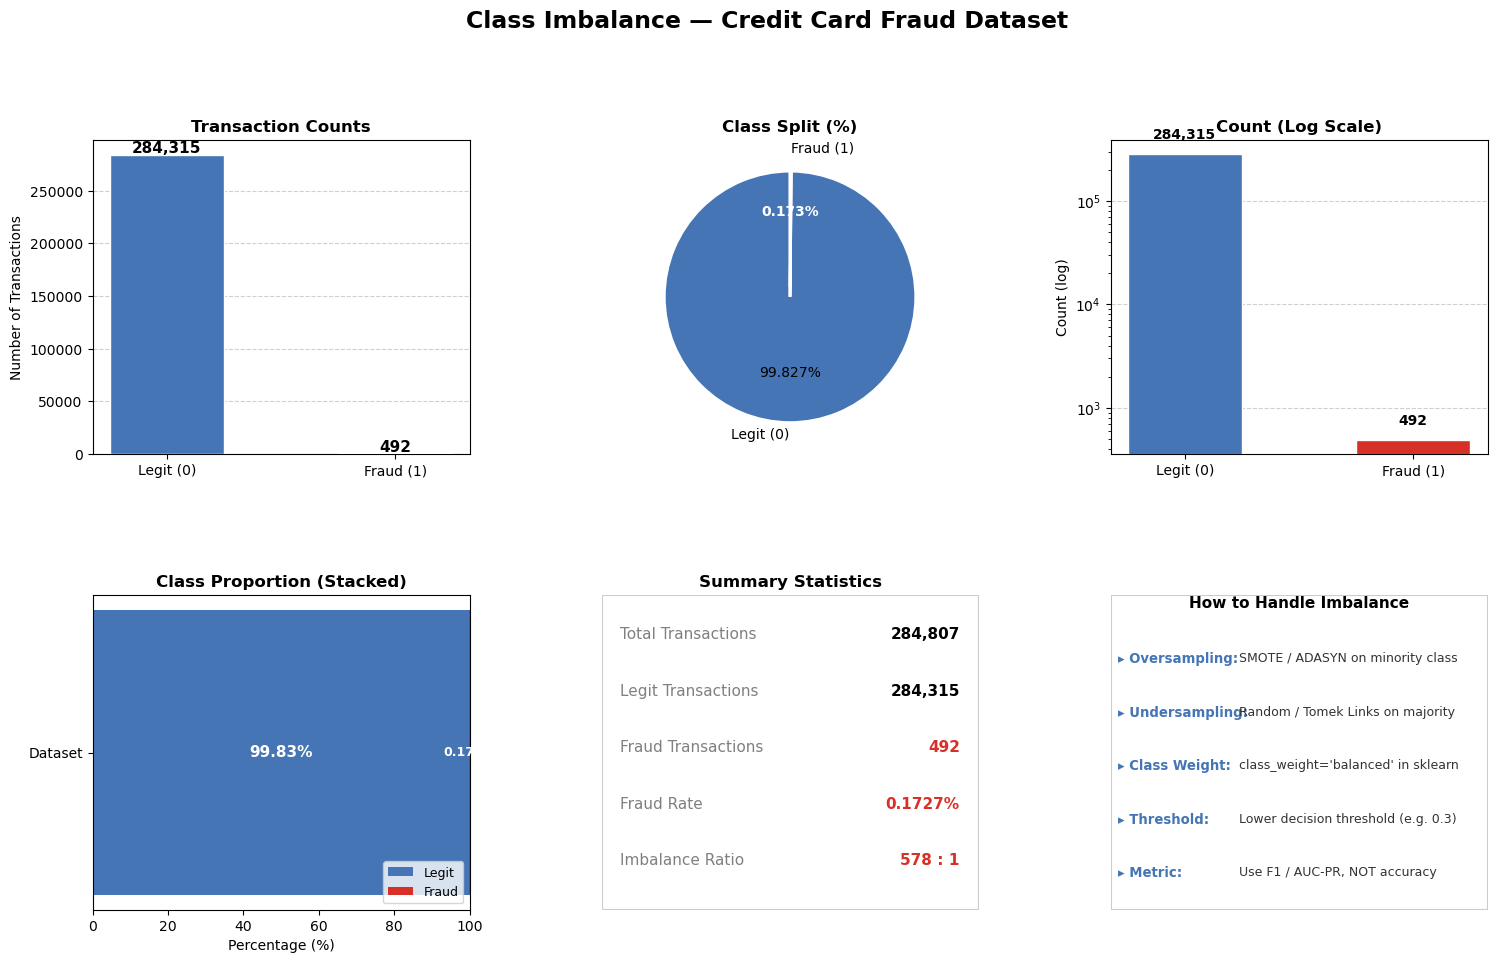

Saved → class_imbalance.png


In [14]:

import matplotlib.gridspec as gridspec



# ── Counts ─────────────────────────────────────────────────────────────────────
counts      = df["Class"].value_counts().sort_index()
labels      = ["Legit (0)", "Fraud (1)"]
colors      = ["#4575b4", "#d73027"]
total       = len(df)
fraud_pct   = counts[1] / total * 100
legit_pct   = counts[0] / total * 100

# ══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 10))
fig.suptitle("Class Imbalance — Credit Card Fraud Dataset",
             fontsize=17, fontweight="bold", y=1.01)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── PLOT 1 — Bar Chart ────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(labels, counts.values, color=colors, edgecolor="white",
               width=0.5, zorder=3)
ax1.set_title("Transaction Counts", fontweight="bold")
ax1.set_ylabel("Number of Transactions")
ax1.yaxis.grid(True, linestyle="--", alpha=0.6)
ax1.set_axisbelow(True)
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1500,
             f"{val:,}", ha="center", fontsize=11, fontweight="bold")

# ── PLOT 2 — Pie Chart ────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
wedges, texts, autotexts = ax2.pie(
    counts.values,
    labels=labels,
    colors=colors,
    autopct="%1.3f%%",
    startangle=90,
    explode=(0, 0.08),          # pop out the fraud slice
    wedgeprops=dict(edgecolor="white", linewidth=2),
    textprops=dict(fontsize=10)
)
autotexts[1].set_fontweight("bold")
autotexts[1].set_color("white")
ax2.set_title("Class Split (%)", fontweight="bold")

# ── PLOT 3 — Log-scale Bar ────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
bars3 = ax3.bar(labels, counts.values, color=colors, edgecolor="white",
                width=0.5, zorder=3)
ax3.set_yscale("log")
ax3.set_title("Count (Log Scale)", fontweight="bold")
ax3.set_ylabel("Count (log)")
ax3.yaxis.grid(True, linestyle="--", alpha=0.6)
ax3.set_axisbelow(True)
for bar, val in zip(bars3, counts.values):
    ax3.text(bar.get_x() + bar.get_width() / 2,
             val * 1.4, f"{val:,}",
             ha="center", fontsize=10, fontweight="bold")

# ── PLOT 4 — Stacked Horizontal Bar (proportion) ──────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.barh(["Dataset"], [legit_pct], color=colors[0], label="Legit", height=0.4)
ax4.barh(["Dataset"], [fraud_pct], left=[legit_pct],
         color=colors[1], label="Fraud", height=0.4)
ax4.set_xlim(0, 100)
ax4.set_xlabel("Percentage (%)")
ax4.set_title("Class Proportion (Stacked)", fontweight="bold")
ax4.legend(loc="lower right", fontsize=9)
ax4.text(legit_pct / 2, 0, f"{legit_pct:.2f}%",
         ha="center", va="center", fontsize=11,
         fontweight="bold", color="white")
ax4.text(legit_pct + fraud_pct / 2, 0, f"{fraud_pct:.3f}%",
         ha="center", va="center", fontsize=9,
         fontweight="bold", color="white")

# ── PLOT 5 — Imbalance Ratio Summary Card ─────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.axis("off")
ratio = counts[0] / counts[1]
summary = [
    ("Total Transactions",  f"{total:,}"),
    ("Legit Transactions",  f"{counts[0]:,}"),
    ("Fraud Transactions",  f"{counts[1]:,}"),
    ("Fraud Rate",          f"{fraud_pct:.4f}%"),
    ("Imbalance Ratio",     f"{ratio:.0f} : 1"),
]
y = 0.9
for label, value in summary:
    ax5.text(0.05, y, label,  fontsize=11, color="gray",      va="top")
    ax5.text(0.95, y, value,  fontsize=11, fontweight="bold",
             va="top", ha="right",
             color="#d73027" if "Fraud" in label or "Ratio" in label else "black")
    y -= 0.18
ax5.set_title("Summary Statistics", fontweight="bold")
ax5.add_patch(plt.Rectangle((0, 0), 1, 1, fill=False,
                              edgecolor="#cccccc", linewidth=1.5,
                              transform=ax5.transAxes))

# ── PLOT 6 — What to do about it ──────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis("off")
techniques = [
    ("Oversampling",  "SMOTE / ADASYN on minority class"),
    ("Undersampling", "Random / Tomek Links on majority"),
    ("Class Weight",  "class_weight='balanced' in sklearn"),
    ("Threshold",     "Lower decision threshold (e.g. 0.3)"),
    ("Metric",        "Use F1 / AUC-PR, NOT accuracy"),
]
ax6.text(0.5, 1.0, "How to Handle Imbalance",
         ha="center", fontsize=11, fontweight="bold", va="top")
y = 0.82
for tech, desc in techniques:
    ax6.text(0.02, y, f"▸ {tech}:",  fontsize=9.5, fontweight="bold", va="top", color="#4575b4")
    ax6.text(0.34, y, desc,           fontsize=9,   va="top", color="#333333")
    y -= 0.17
ax6.add_patch(plt.Rectangle((0, 0), 1, 1, fill=False,
                              edgecolor="#cccccc", linewidth=1.5,
                              transform=ax6.transAxes))

plt.savefig("class_imbalance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → class_imbalance.png")

# Function that Returns new Data frame with best possible combination

In [24]:
# def append_best_model_full(results, model_name, final_df=None):
#     best_row = results.sort_values(
#         'mean_test_score', ascending=False
#     ).head(1).copy()
    
#     best_row["Model_name"] = model_name
    
#     if final_df is None:
#         final_df = best_row
#     else:
#         final_df = pd.concat([final_df, best_row], ignore_index=True)
    
#     return final_df

In [ ]:
# model_results_dict = {
#     "EasyEnsemble": results_easy,
#     "LightGBM": results_lightgbm,
#     "XGBoost": results_xg
# }


# final_results = None

# for model_name, results in model_results_dict.items():
#     final_results = append_best_model_full(
#         results=results,
#         model_name=model_name,
#         final_df=final_results
#     )

# best_model = final_results.sort_values(
#     "mean_test_score", ascending=False
# ).head(1)

# best_model.columns

In [ ]:
# cols_to_keep = [
#     "mean_test_score",
#     "std_test_score",
#     "rank_test_score",

#     "param_n_estimators",
#     "param_learning_rate",
#     "param_num_leaves",
#     "param_max_depth",
#     "param_min_child_samples",
#     "param_subsample",
#     "param_colsample_bytree",
#     "param_class_weight",
#     "param_scale_pos_weight"
# ]

# final_results = best_model[cols_to_keep].sort_values("rank_test_score")
# final_results